In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
VALID_ACTIVITIES = [
    "Breathing", "Counting1", "Counting2", "Counting3",
    "Math", "Reading", "Relax", "Speaking",
    "Stroop", "Video1", "Video2"
]

def clean_activity(x):
    x = str(x).strip().replace(" ", "").replace("-", "").replace("_", "")
    lookup = {a.lower(): a for a in VALID_ACTIVITIES}
    return lookup.get(x.lower(), x)

def load_gt(path):
    gt = pd.read_csv(path, sep=";")
    gt = gt[["subject/task", "binary-stress"]].copy()

    gt = gt.rename(columns={
        "subject/task": "subject_activity",
        "binary-stress": "y_true"
    })

    gt["y_true"] = gt["y_true"].astype(int)

    return gt

def load_res(path):
    res = pd.read_csv(path)

    res["subject"] = res["subject"].astype(str).str.strip()
    res["activity"] = res["activity"].astype(str).str.strip()

    res["subject_activity"] = res["subject"] + "_" + res["activity"]

    res["window_id"] = pd.to_numeric(res["window_id"], errors="coerce")
    res["stress_level"] = pd.to_numeric(res["stress_level"], errors="coerce")
    res["binary_stress"] = pd.to_numeric(res["binary_stress"], errors="coerce").astype("Int64")
    res["confidence"] = pd.to_numeric(res["confidence"], errors="coerce")

    return res

import numpy as np
import pandas as pd

def make_eval_df(
    res,
    gt,
    aggregation="any_binary",
    stress_threshold=5.0,
    top_k=3
):
    """
    Aggregates window-level video predictions into task-level predictions.

    Expected columns:
        res: subject_activity, binary_stress, stress_level, confidence
        gt:  subject_activity, y_true

    Aggregations:
        any_binary                 -> stress if any window predicts stress
        majority_binary            -> stress if >= 50% windows predict stress
        mean_score                 -> mean stress_level, then threshold
        median_score               -> median stress_level, then threshold
        max_score                  -> max stress_level, then threshold
        topk_mean_score            -> mean of top-k stress_level values, then threshold
        confidence_weighted_score  -> confidence-weighted mean stress_level, then threshold
    """

    df = res.copy()

    # Remove invalid binary predictions
    df = df[df["binary_stress"].isin([0, 1])].copy()

    df["binary_stress"] = df["binary_stress"].astype(int)
    df["stress_level"] = pd.to_numeric(df["stress_level"], errors="coerce")
    df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")

    rows = []

    for subject_activity, group in df.groupby("subject_activity"):
        binary_values = group["binary_stress"].dropna().astype(int)
        scores = group["stress_level"].dropna()

        if aggregation == "any_binary":
            pred_score = binary_values.max()
            y_pred = int(pred_score >= 1)

        elif aggregation == "majority_binary":
            pred_score = binary_values.mean()
            y_pred = int(pred_score >= 0.5)

        elif aggregation == "mean_score":
            pred_score = scores.mean()
            y_pred = int(pred_score >= stress_threshold)

        elif aggregation == "median_score":
            pred_score = scores.median()
            y_pred = int(pred_score >= stress_threshold)

        elif aggregation == "max_score":
            pred_score = scores.max()
            y_pred = int(pred_score >= stress_threshold)

        elif aggregation == "topk_mean_score":
            k = min(top_k, len(scores))
            pred_score = scores.sort_values(ascending=False).head(k).mean()
            y_pred = int(pred_score >= stress_threshold)

        elif aggregation == "confidence_weighted_score":
            valid = group.dropna(subset=["stress_level", "confidence"]).copy()

            if len(valid) == 0:
                continue

            if valid["confidence"].sum() == 0:
                pred_score = valid["stress_level"].mean()
            else:
                pred_score = np.average(
                    valid["stress_level"],
                    weights=valid["confidence"]
                )

            y_pred = int(pred_score >= stress_threshold)

        else:
            raise ValueError(f"Unknown aggregation method: {aggregation}")

        rows.append({
            "subject_activity": subject_activity,
            "y_pred": y_pred,
            "pred_score": pred_score,
            "n_windows": len(group),
            "aggregation": aggregation
        })

    pred_task = pd.DataFrame(rows)

    eval_df = gt.merge(
        pred_task,
        on="subject_activity",
        how="inner"
    )

    eval_df["y_true"] = eval_df["y_true"].astype(int)
    eval_df["y_pred"] = eval_df["y_pred"].astype(int)

    return eval_df

def plot_confusion_matrix(eval_df, title):
    print("Evaluated tasks:", len(eval_df))
    print()
    print(classification_report(eval_df["y_true"], eval_df["y_pred"], digits=3))

    cm = confusion_matrix(
        eval_df["y_true"],
        eval_df["y_pred"],
        labels=[0, 1]
    )

    plt.figure(figsize=(6, 5))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        xticklabels=["No Stress", "Stress"],
        yticklabels=["No Stress", "Stress"],
        square=True,
        linewidths=1.5,
        linecolor="white",
        cbar=True,
        annot_kws={"size": 16, "weight": "bold"}
    )

    ax.set_title(title, fontsize=14, weight="bold", pad=14)
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("Ground-truth label", fontsize=12)

    plt.tight_layout()
    plt.show()

import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

def plot_all_aggregation_confusion_matrices(
    res,
    gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation method comparison"
):
    aggregations = [
        "any_binary",
        "majority_binary",
        "mean_score",
        "median_score",
        "max_score",
        "topk_mean_score",
        "confidence_weighted_score"
    ]

    pretty_names = {
        "any_binary": "Any-window",
        "majority_binary": "Majority vote",
        "mean_score": "Mean score",
        "median_score": "Median score",
        "max_score": "Max score",
        "topk_mean_score": f"Top-{top_k} mean",
        "confidence_weighted_score": "Confidence-weighted"
    }

    results = []

    for aggregation in aggregations:
        eval_df = make_eval_df(
            res=res,
            gt=gt,
            aggregation=aggregation,
            stress_threshold=stress_threshold,
            top_k=top_k
        )

        y_true = eval_df["y_true"]
        y_pred = eval_df["y_pred"]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        results.append({
            "aggregation": aggregation,
            "pretty_name": pretty_names[aggregation],
            "eval_df": eval_df,
            "cm": cm,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "n": len(eval_df)
        })

    n_plots = len(results)
    n_cols = 4
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    vmax = max(r["cm"].max() for r in results)

    for ax, r in zip(axes, results):
        sns.heatmap(
            r["cm"],
            annot=True,
            fmt="d",
            cmap=cmap,
            vmin=0,
            vmax=vmax,
            cbar=False,
            square=True,
            linewidths=1.5,
            linecolor="white",
            xticklabels=["No Stress", "Stress"],
            yticklabels=["No Stress", "Stress"],
            ax=ax
        )

        ax.set_title(
            f"{r['pretty_name']}\n"
            f"Bal Acc={r['balanced_accuracy']:.3f} | F1={r['f1']:.3f}",
            fontsize=11,
            pad=10
        )

        ax.set_xlabel("Predicted")
        ax.set_ylabel("Ground truth")
        ax.tick_params(axis="both", labelsize=9)

    # Hide unused subplot axes
    for ax in axes[len(results):]:
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    plt.show()

    # Return compact metric table too
    summary_df = pd.DataFrame([
        {
            "aggregation": r["aggregation"],
            "accuracy": r["accuracy"],
            "balanced_accuracy": r["balanced_accuracy"],
            "f1": r["f1"],
            "n": r["n"]
        }
        for r in results
    ]).sort_values("balanced_accuracy", ascending=False)

    return summary_df

In [3]:
def prepare_gt_binary(gt):
    """
    Keeps only the binary ground truth and creates a subject_activity key.
    Ignores affect3-class and affect3-class-v2.
    """
    gt_binary = gt.rename(
        columns={
            "subject/task": "subject_activity",
            "binary-stress": "y_true"
        }
    )[["subject_activity", "y_true"]].copy()

    gt_binary["y_true"] = gt_binary["y_true"].astype(int)

    return gt_binary

def aggregate_video_predictions(
    res,
    aggregation="any_binary",
    stress_threshold=5.0
):
    """
    Aggregates window-level video predictions into one prediction per subject-activity.

    Available aggregation methods:

    any_binary:
        Current method. If any window predicts stress, the whole task is stress.

    majority_binary:
        Stress if at least half the windows predict stress.

    mean_score:
        Average stress_level over windows, then threshold.

    median_score:
        Median stress_level over windows, then threshold.

    max_score:
        Maximum stress_level over windows, then threshold.

    confidence_weighted_score:
        Weighted average of stress_level using confidence, then threshold.
    """

    df = res.copy()

    # Remove invalid predictions
    df = df.query("binary_stress != -1").copy()

    df["subject_activity"] = (
        df["subject"].astype(str) + "_" + df["activity"].astype(str)
    )

    df["binary_stress"] = df["binary_stress"].astype(int)

    if "stress_level" in df.columns:
        df["stress_level"] = pd.to_numeric(df["stress_level"], errors="coerce")

    if "confidence" in df.columns:
        df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")

    rows = []

    for subject_activity, group in df.groupby("subject_activity"):

        binary_values = group["binary_stress"].values

        if aggregation == "any_binary":
            score = binary_values.max()
            y_pred = int(score >= 1)

        elif aggregation == "majority_binary":
            score = binary_values.mean()
            y_pred = int(score >= 0.5)

        elif aggregation == "mean_score":
            score = group["stress_level"].mean()
            y_pred = int(score >= stress_threshold)

        elif aggregation == "median_score":
            score = group["stress_level"].median()
            y_pred = int(score >= stress_threshold)

        elif aggregation == "max_score":
            score = group["stress_level"].max()
            y_pred = int(score >= stress_threshold)

        elif aggregation == "confidence_weighted_score":
            valid = group.dropna(subset=["stress_level", "confidence"])

            if len(valid) == 0:
                score = np.nan
                y_pred = np.nan
            elif valid["confidence"].sum() == 0:
                score = valid["stress_level"].mean()
                y_pred = int(score >= stress_threshold)
            else:
                score = np.average(
                    valid["stress_level"],
                    weights=valid["confidence"]
                )
                y_pred = int(score >= stress_threshold)

        else:
            raise ValueError(f"Unknown aggregation method: {aggregation}")

        rows.append({
            "subject_activity": subject_activity,
            "y_pred": y_pred,
            "pred_score": score,
            "n_windows": len(group),
            "aggregation": aggregation
        })

    pred_df = pd.DataFrame(rows)

    pred_df = pred_df.dropna(subset=["y_pred"]).copy()
    pred_df["y_pred"] = pred_df["y_pred"].astype(int)

    return pred_df

def get_eval_per_subject_act_df(
    res,
    gt,
    aggregation="any_binary",
    stress_threshold=5.0
):
    """
    Converts window-level predictions into task-level predictions
    and joins them with binary ground truth.
    """

    gt_binary = prepare_gt_binary(gt)

    pred_df = aggregate_video_predictions(
        res=res,
        aggregation=aggregation,
        stress_threshold=stress_threshold
    )

    eval_df = pd.merge(
        gt_binary,
        pred_df,
        on="subject_activity",
        how="inner"
    )

    return eval_df

def print_results(
    res,
    gt,
    aggregation="any_binary",
    stress_threshold=5.0,
    title=None,
    cmap="YlGnBu"
):
    eval_df = get_eval_per_subject_act_df(
        res=res,
        gt=gt,
        aggregation=aggregation,
        stress_threshold=stress_threshold
    )

    if title is None:
        title = f"Video stress prediction — {aggregation}"

    y_true = eval_df["y_true"].astype(int)
    y_pred = eval_df["y_pred"].astype(int)

    print(f"\nAggregation: {aggregation}")
    print(f"N evaluated tasks: {len(eval_df)}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(6.5, 5.2))

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["No Stress", "Stress"],
        yticklabels=["No Stress", "Stress"],
        cbar=True,
        square=True,
        linewidths=1.5,
        linecolor="white",
        annot_kws={"size": 16, "weight": "bold"}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Ground-truth label")

    ax.tick_params(axis="both")

    plt.tight_layout()
    plt.show()

    return eval_df

In [6]:

INFERENCE_RUNS = [
    {
        "path": "../results/Qwen3_VL_4B_Instruct_5s1fps_cropped_results.csv",
        "window_size": 5,
        "fps": 1,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_5s2fps_cropped_results.csv",
        "window_size": 5,
        "fps": 2,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_5s5fps_cropped_results.csv",
        "window_size": 5,
        "fps": 5,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_10s1fps_cropped_results.csv",
        "window_size": 10,
        "fps": 1,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_10s2fps_cropped_results.csv",
        "window_size": 10,
        "fps": 2,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_10s5fps_cropped_results.csv",
        "window_size": 10,
        "fps": 5,
        "overlap":0
    },
    {
        "path": "../results/Qwen3_VL_4B_Instruct_5s5fps_20overlap_cropped_results.csv",
        "window_size": 5,
        "fps": 5,
        "overlap":0.2
    }
]

def create_video_summary_csv(
    inference_runs,
    gt,
    output_path="video_summary_binary_results.csv",
    stress_threshold=5.0,
    top_k=3
):
    """
    Creates a CSV with one row per:
        window_size x fps x aggregation

    Output columns:
        window_size
        fps
        aggregation
        accuracy
        balanced_accuracy
        f1
        precision
        recall
        n_tasks
    """

    aggregations = [
        "any_binary",
        "majority_binary",
        "mean_score",
        "median_score",
        #"max_score",
        "topk_mean_score",
        "confidence_weighted_score"
    ]

    rows = []

    for run in inference_runs:
        path = run["path"]
        window_size = run["window_size"]
        fps = run["fps"]
        overlap = run["overlap"]

        print(f"Processing: {path}")

        res = load_res(path)

        for aggregation in aggregations:
            eval_df = make_eval_df(
                res=res,
                gt=gt,
                aggregation=aggregation,
                stress_threshold=stress_threshold,
                top_k=top_k
            )

            y_true = eval_df["y_true"]
            y_pred = eval_df["y_pred"]

            rows.append({
                "path": path,
                "window_size": window_size,
                "fps": fps,
                "overlap": overlap,
                "aggregation": aggregation,
                "accuracy": accuracy_score(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "n_tasks": len(eval_df)
            })

    summary_df = pd.DataFrame(rows)

    summary_df = summary_df.sort_values(
        by=["balanced_accuracy", "f1", "accuracy"],
        ascending=False
    )

    output_path = Path(output_path)
    summary_df.to_csv(output_path, index=False)

    print(f"Saved summary CSV to: {output_path}")

    return summary_df

Antes de la evaluación con el GT, se debe realizar una agregación de los resultados obtenidos por ventana, probaremos con las siguientes:

|Aggregation | Meaning|
------------|---------
|any_binary|Tarea estresante si alguna ventana es estresante|
|majority_binary|Tarea estresante si la mayoría de las ventanas son estresantes|
|mean_score|Media de los scores obtenidos, y aplicar un umbral (0.5 por defecto)|
|max_score|Tarea estresante si la ventana con mayor score es estresante|
|confidence_weighted_score|Scores ponderados por la confianza del modelo|

# Mejor configuración temporal:

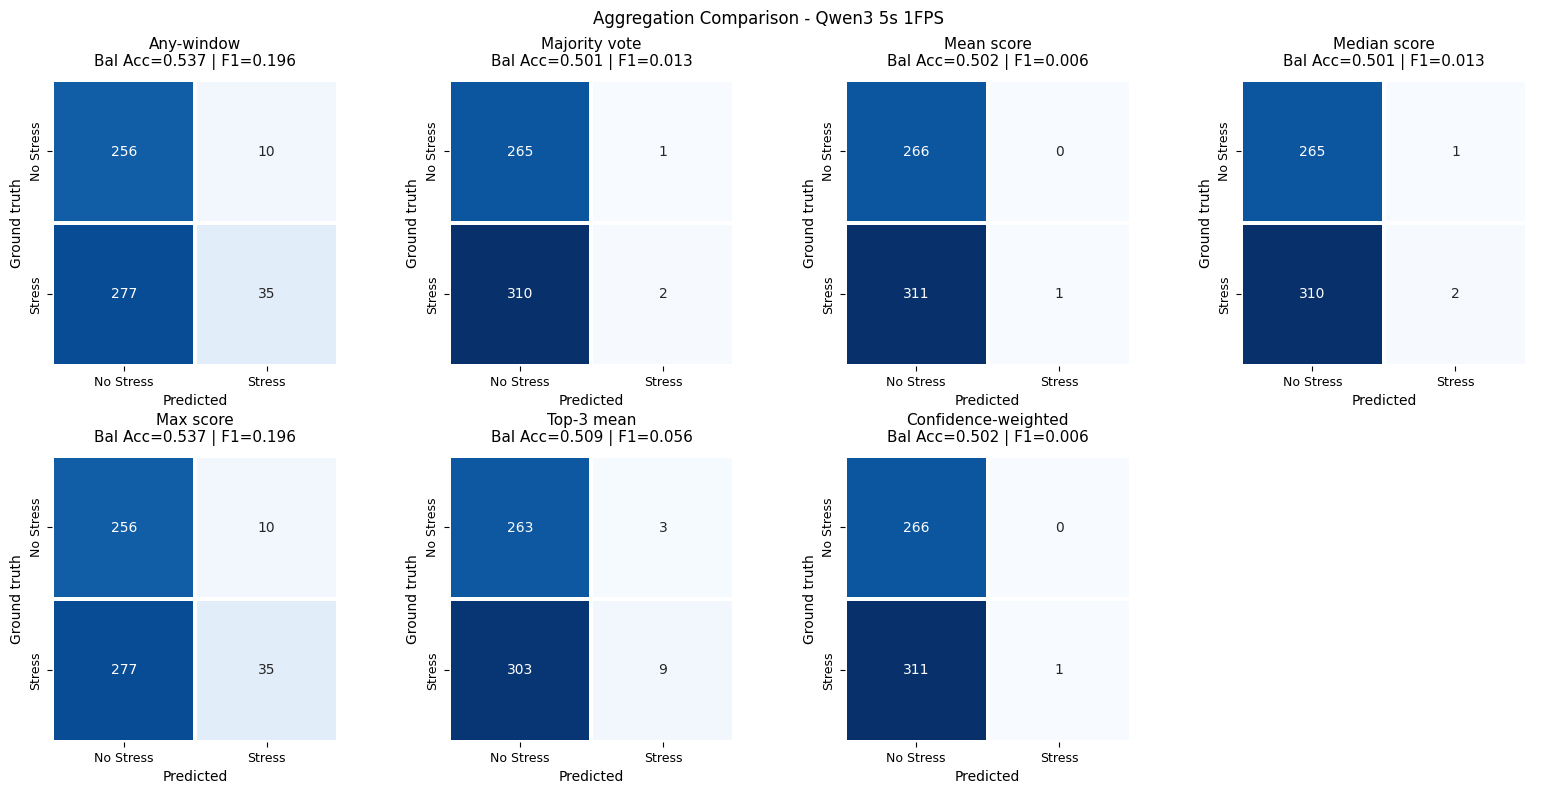

In [9]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_5s1fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 5s 1FPS"
)

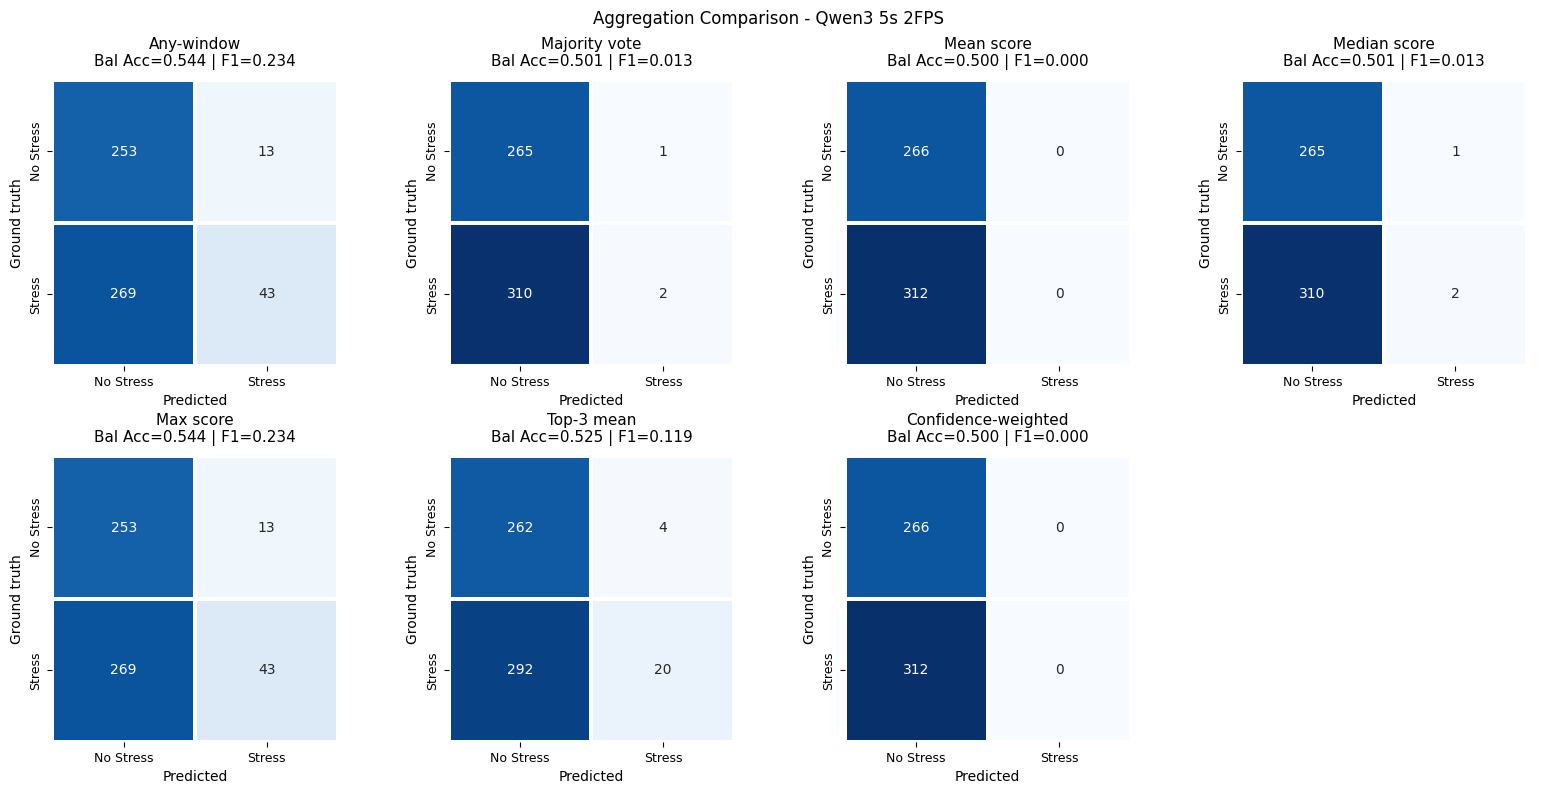

In [11]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_5s2fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 5s 2FPS"
)

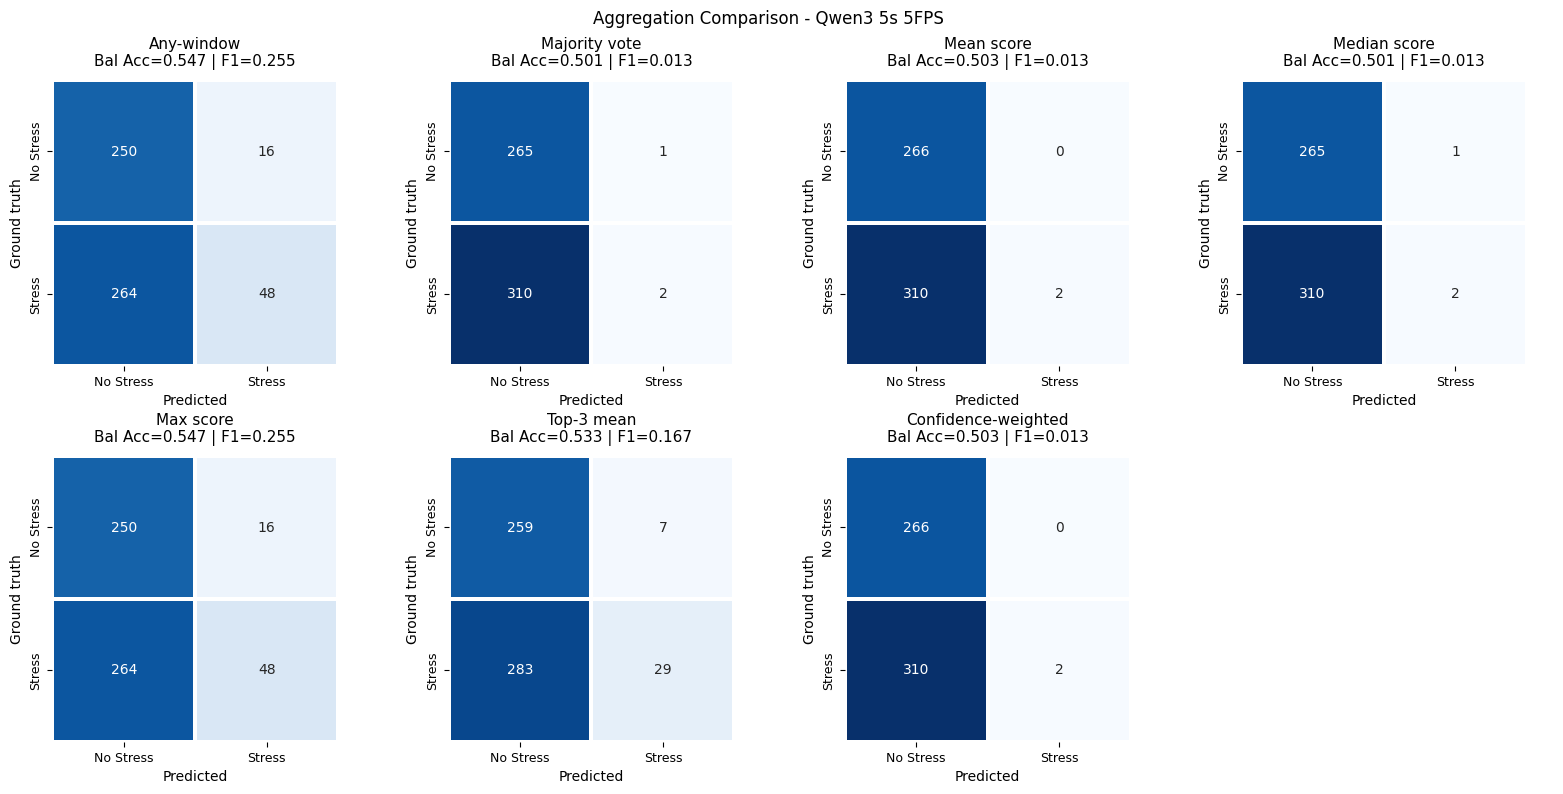

In [12]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_5s5fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 5s 5FPS"
)

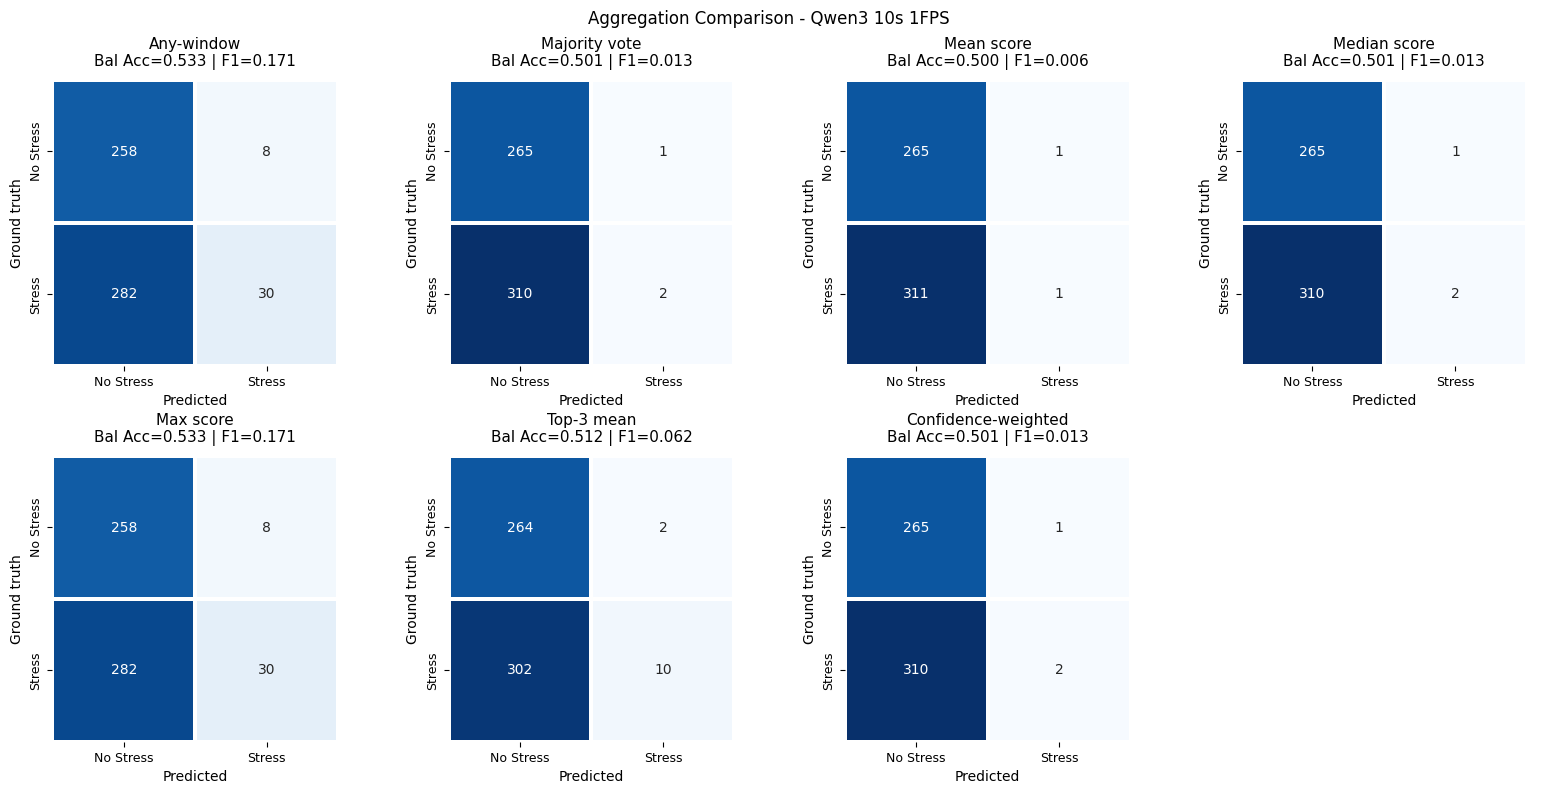

In [14]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_10s1fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 10s 1FPS"
)

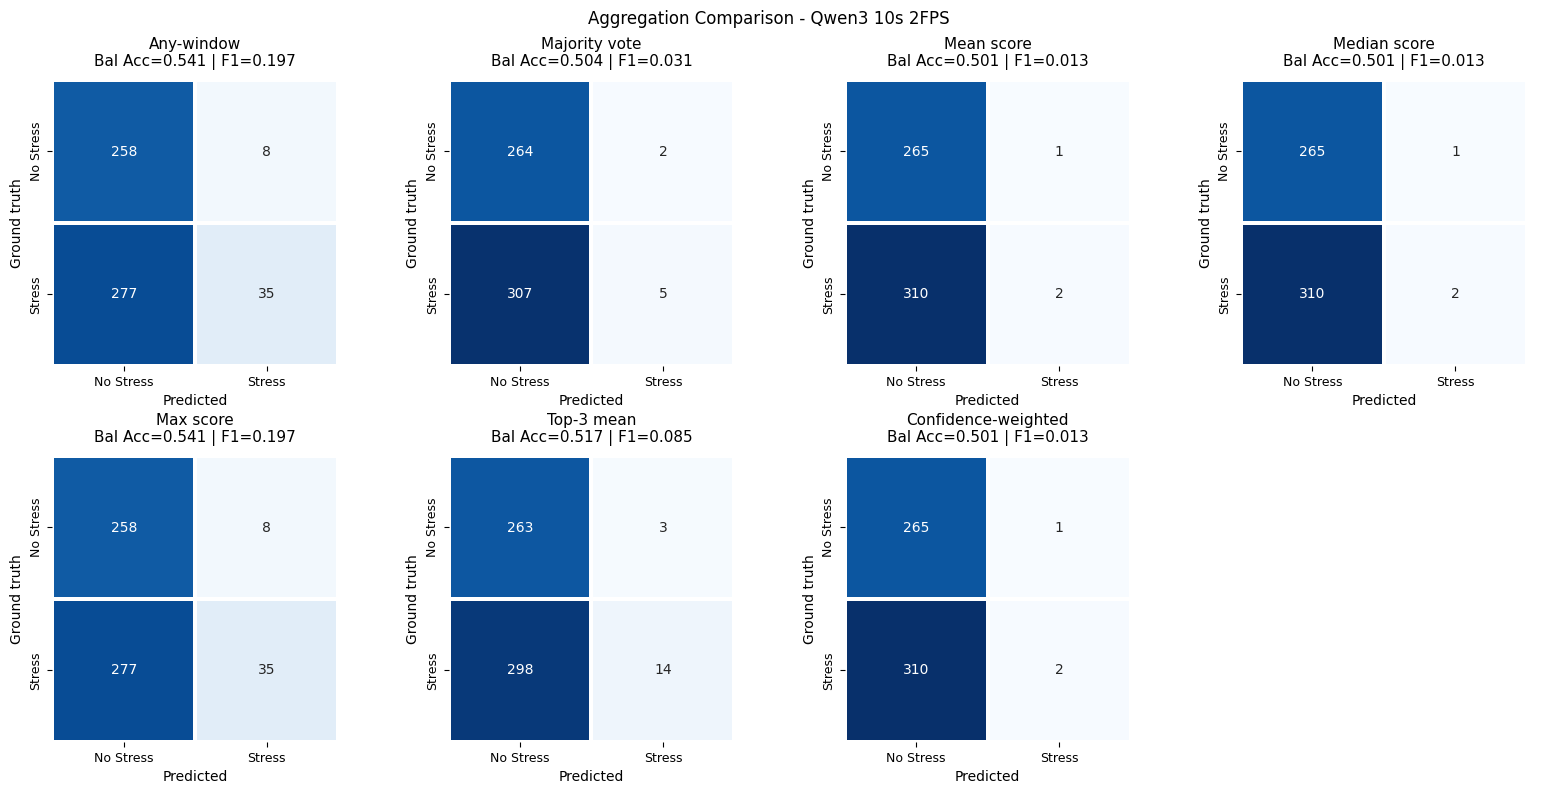

In [15]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_10s2fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 10s 2FPS"
)

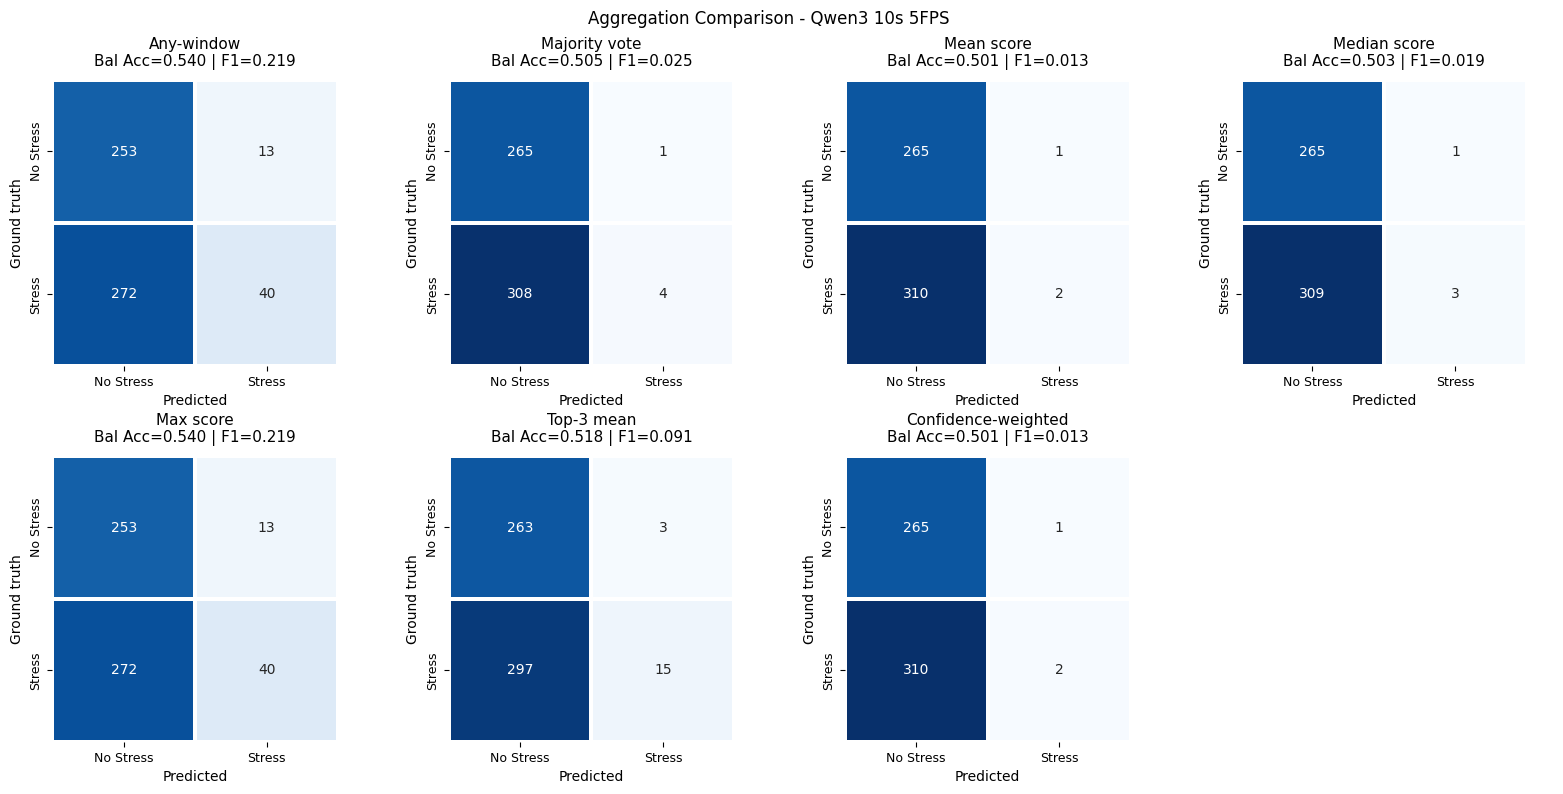

In [16]:
GT_PATH = "../data/labels_v2.csv"
RES_PATH = "../results/Qwen3_VL_4B_Instruct_10s5fps_cropped_results.csv" 


gt = load_gt(GT_PATH)
res = load_res(RES_PATH)

aggregation_summary = plot_all_aggregation_confusion_matrices(
    res=res,
    gt=gt,
    stress_threshold=5.0,
    top_k=3,
    cmap="Blues",
    title="Aggregation Comparison - Qwen3 10s 5FPS"
)

In [18]:
summary_df = create_video_summary_csv(
    inference_runs=INFERENCE_RUNS,
    gt=gt,
    output_path="../results/native_video_binaryclassification_results.csv",
    stress_threshold=5.0,
    top_k=3
)

Processing: ../results/Qwen3_VL_4B_Instruct_5s1fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_5s2fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_5s5fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_10s1fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_10s2fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_10s5fps_cropped_results.csv
Processing: ../results/Qwen3_VL_4B_Instruct_5s5fps_20overlap_cropped_results.csv
Saved summary CSV to: ../results/native_video_binaryclassification_results.csv


In [19]:
summary_df.sort_values('balanced_accuracy', ascending=False)

,path,window_size,fps,overlap,aggregation,accuracy,balanced_accuracy,f1,precision,recall,n_tasks
12,../results/Qwen3_VL_4B_Instruct_5s5fps_cropped...,5,5,0.0,any_binary,0.515571,0.546848,0.255319,0.750000,0.153846,578
36,../results/Qwen3_VL_4B_Instruct_5s5fps_20overl...,5,5,0.2,any_binary,0.513841,0.545245,0.250667,0.746032,0.150641,578
6,../results/Qwen3_VL_4B_Instruct_5s2fps_cropped...,5,2,0.0,any_binary,0.512111,0.544474,0.233696,0.767857,0.137821,578
24,../results/Qwen3_VL_4B_Instruct_10s2fps_croppe...,10,2,0.0,any_binary,0.506920,0.541052,0.197183,0.813953,0.112179,578
30,../results/Qwen3_VL_4B_Instruct_10s5fps_croppe...,10,5,0.0,any_binary,0.506920,0.539666,0.219178,0.754717,0.128205,578
0,../results/Qwen3_VL_4B_Instruct_5s1fps_cropped...,5,1,0.0,any_binary,0.503460,0.537293,0.196078,0.777778,0.112179,578
40,../results/Qwen3_VL_4B_Instruct_5s5fps_20overl...,5,5,0.2,topk_mean_score,0.500000,0.534919,0.171920,0.810811,0.096154,578
16,../results/Qwen3_VL_4B_Instruct_5s5fps_cropped...,5,5,0.0,topk_mean_score,0.498270,0.533316,0.166667,0.805556,0.092949,578
18,../results/Qwen3_VL_4B_Instruct_10s1fps_croppe...,10,1,0.0,any_binary,0.498270,0.533039,0.171429,0.789474,0.096154,578
10,../results/Qwen3_VL_4B_Instruct_5s2fps_cropped...,5,2,0.0,topk_mean_score,0.487889,0.524532,0.119048,0.833333,0.064103,578


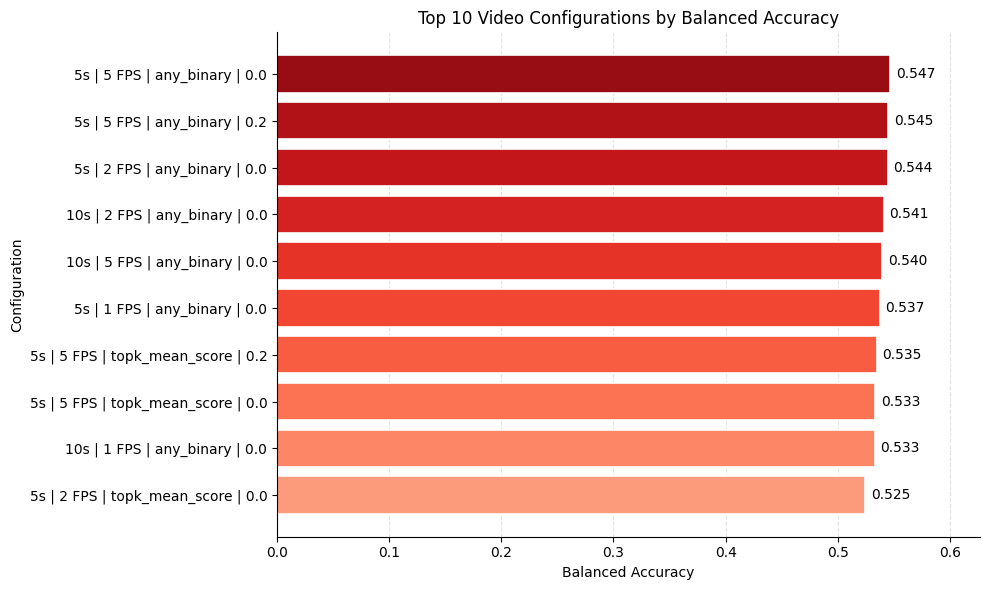

,path,window_size,fps,overlap,aggregation,accuracy,balanced_accuracy,f1,precision,recall,n_tasks,config
12,../results/Qwen3_VL_4B_Instruct_5s5fps_cropped...,5,5,0.0,any_binary,0.515571,0.546848,0.255319,0.750000,0.153846,578,5s | 5 FPS | any_binary | 0.0
36,../results/Qwen3_VL_4B_Instruct_5s5fps_20overl...,5,5,0.2,any_binary,0.513841,0.545245,0.250667,0.746032,0.150641,578,5s | 5 FPS | any_binary | 0.2
6,../results/Qwen3_VL_4B_Instruct_5s2fps_cropped...,5,2,0.0,any_binary,0.512111,0.544474,0.233696,0.767857,0.137821,578,5s | 2 FPS | any_binary | 0.0
24,../results/Qwen3_VL_4B_Instruct_10s2fps_croppe...,10,2,0.0,any_binary,0.506920,0.541052,0.197183,0.813953,0.112179,578,10s | 2 FPS | any_binary | 0.0
30,../results/Qwen3_VL_4B_Instruct_10s5fps_croppe...,10,5,0.0,any_binary,0.506920,0.539666,0.219178,0.754717,0.128205,578,10s | 5 FPS | any_binary | 0.0
0,../results/Qwen3_VL_4B_Instruct_5s1fps_cropped...,5,1,0.0,any_binary,0.503460,0.537293,0.196078,0.777778,0.112179,578,5s | 1 FPS | any_binary | 0.0
40,../results/Qwen3_VL_4B_Instruct_5s5fps_20overl...,5,5,0.2,topk_mean_score,0.500000,0.534919,0.171920,0.810811,0.096154,578,5s | 5 FPS | topk_mean_score | 0.2
16,../results/Qwen3_VL_4B_Instruct_5s5fps_cropped...,5,5,0.0,topk_mean_score,0.498270,0.533316,0.166667,0.805556,0.092949,578,5s | 5 FPS | topk_mean_score | 0.0
18,../results/Qwen3_VL_4B_Instruct_10s1fps_croppe...,10,1,0.0,any_binary,0.498270,0.533039,0.171429,0.789474,0.096154,578,10s | 1 FPS | any_binary | 0.0
10,../results/Qwen3_VL_4B_Instruct_5s2fps_cropped...,5,2,0.0,topk_mean_score,0.487889,0.524532,0.119048,0.833333,0.064103,578,5s | 2 FPS | topk_mean_score | 0.0


In [22]:

def plot_top_video_configs(
    summary_df,
    metric="balanced_accuracy",
    top_n=10,
    title=None,
    save_path=None,
    cmap="Reds"
):
    """
    Plots the top-N video configurations from the aggregated summary dataframe.

    Expected columns:
        window_size, fps, aggregation, accuracy, balanced_accuracy, f1
    """

    df = summary_df.copy()

    df = df.sort_values(metric, ascending=False).head(top_n)

    df["config"] = (
        df["window_size"].astype(int).astype(str) + "s"
        + " | " + df["fps"].astype(int).astype(str) + " FPS"
        + " | " + df["aggregation"].astype(str)
        + " | " + df["overlap"].astype(str)
    )

    df = df.sort_values(metric, ascending=True)

    colors = plt.get_cmap(cmap)(np.linspace(0.35, 0.9, len(df)))

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        df["config"],
        df[metric],
        color=colors,
        edgecolor="white",
        linewidth=1.2
    )

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.3f}",
            va="center",
            fontsize=10
        )

    metric_label = metric.replace("_", " ").title()

    if title is None:
        title = f"Top {top_n} Video Configurations by {metric_label}"

    ax.set_title(title)
    ax.set_xlabel(metric_label)
    ax.set_ylabel("Configuration")

    ax.set_xlim(0, min(1.05, max(df[metric].max() + 0.08, 0.1)))

    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return df.sort_values(metric, ascending=False)

top_configs = plot_top_video_configs(
    summary_df,
    metric="balanced_accuracy",
    top_n=10,
    save_path="top_video_configs_balanced_accuracy.png"
)

top_configs

# Qwen 3 4B results by Balanced Accuracy:

|Config|**Any window**|Majority vote| Mean score | Median score| Top-3 Mean | Confidence weighted|
|---|-------|------------|--------------|-----------|-------------|---------------|
|5s 1FPS|0.537|0.501|0.502|0.501|0.509|0.502|
|5s 2FPS|0.544|0.501|0.500|0.501|0.525|0.500|
|**5s 5FPS**|**0.547**|0.501|0.503|0.501|0.533|0.503|
|10s 1FPS|0.533|0.501|0.500|0.501|0.512|0.501|
|10s 2FPS|0.541|0.504|0.501|0.501|0.517|0.501|
|10s 5FPS|0.540|0.505|0.501|0.503|0.518|0.501|